In [4]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# SSL/PROXY CONFIGURATION - MUST BE BEFORE wandb IMPORT
# ============================================================
import os
import ssl

# Set proxy for Python requests/urllib
PROXY_HOST = "proxy.infet.ejpd.admin.ch"
PROXY_PORT = "8080"
PROXY_URL = f"http://{PROXY_HOST}:{PROXY_PORT}"

# Configure proxies for different protocols
os.environ['http_proxy'] = PROXY_URL
os.environ['https_proxy'] = PROXY_URL
os.environ['HTTP_PROXY'] = PROXY_URL
os.environ['HTTPS_PROXY'] = PROXY_URL

# DISABLE SSL VERIFICATION FOR CORPORATE PROXY (CRITICAL)
os.environ['REQUESTS_CA_BUNDLE'] = ''
os.environ['CURL_CA_BUNDLE'] = ''
os.environ['PYTHONHTTPSVERIFY'] = '0'
os.environ['INSECURE_REQUESTS_DISABLED'] = 'false'

# Disable SSL warnings
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Configure SSL to NOT verify certificates
ssl.verify_mode = ssl.CERT_NONE
ssl._create_default_https_context = ssl._create_unverified_context

# CRITICAL: Configure urllib3 to not verify SSL at the package level
from urllib3.util.ssl_ import create_urllib3_context
context = create_urllib3_context()
context.check_hostname = False
context.verify_mode = ssl.CERT_NONE

# Configure requests library with SSL disabled
import requests
from requests.adapters import HTTPAdapter
from urllib3.poolmanager import PoolManager

class SSLAdapter(HTTPAdapter):
    """HTTPAdapter that disables SSL verification"""
    def init_poolmanager(self, *args, **kwargs):
        ctx = create_urllib3_context()
        ctx.check_hostname = False
        ctx.verify_mode = ssl.CERT_NONE
        kwargs['ssl_context'] = ctx
        return super().init_poolmanager(*args, **kwargs)

session = requests.Session()
session.mount('https://', SSLAdapter())
session.mount('http://', SSLAdapter())

# yfinance will use the proxy and SSL settings from environment variables
# The session is configured above with SSL verification disabled

print("✓ SSL/Proxy configured:")
print(f"  Host: {PROXY_HOST}")
print(f"  Port: {PROXY_PORT}")
print(f"  SSL Verification: DISABLED (corporate proxy)")
print(f"  Environment variables set for yfinance")
print(f"  urllib3 SSL: DISABLED")

# ============================================================
# WANDB API KEY & CONFIGURATION
# ============================================================
WANDB_API_KEY = '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'
os.environ['WANDB_API_KEY'] = WANDB_API_KEY

# W&B configuration - Use OFFLINE mode to avoid SSL errors with corporate proxy
# Metrics will be saved locally in ./wandb/ and can be synced to cloud later
os.environ['WANDB_MODE'] = 'offline'
os.environ['WANDB_SILENT'] = 'false'
os.environ['VERIFY_SSL'] = 'false'
os.environ['SSL_NO_VERIFY'] = '1'

# Configure matplotlib
os.environ['MPLBACKEND'] = 'Agg'

print(f"✓ WANDB_API_KEY: {WANDB_API_KEY[:30]}...")
print("✓ W&B Mode: OFFLINE (metrics saved locally, no SSL issues)")
print("  → Metrics saved to: ./wandb/")
print("  → Sync to cloud later with: wandb sync ./wandb/offline-run-*/")

# Weights & Biases Integration
try:
    import wandb
    WANDB_AVAILABLE = True
except ImportError:
    WANDB_AVAILABLE = False
    print("Warning: wandb not available. Install with: pip install wandb")

# Plotting setup
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 10


✓ SSL/Proxy configured:
  Host: proxy.infet.ejpd.admin.ch
  Port: 8080
  SSL Verification: DISABLED (corporate proxy)
  Environment variables set for yfinance
  urllib3 SSL: DISABLED
✓ WANDB_API_KEY: wandb_v1_JDuUyekrsnKF24xmzMNoF...
✓ W&B Mode: OFFLINE (metrics saved locally, no SSL issues)
  → Metrics saved to: ./wandb/
  → Sync to cloud later with: wandb sync ./wandb/offline-run-*/


# WANDB LOGIN & SETUP

In [5]:
# ============================================================
# WEIGHTS & BIASES LOGIN & CONFIGURATION
# ============================================================
print("="*70)
print("WEIGHTS & BIASES SETUP")
print("="*70)

WANDB_PROJECT_PPO = "PPO_Bitcoin_Extended_Env"
WANDB_PROJECT_FORECAST = "PPO_Bitcoin_Forecast"
WANDB_GROUP = "dennis"
WANDB_ENTITY = 'btcprojekt2026-bfh'
USE_WANDB = WANDB_AVAILABLE

if USE_WANDB:
    print("\n✓ W&B configuration:")
    print(f"  Project: {WANDB_PROJECT_PPO}")
    print(f"  Entity: {WANDB_ENTITY}")
    print(f"  SSL: DISABLED (corporate proxy)")
    print(f"  Mode: ONLINE (metrics logged in real-time)")
    print("\n✓ API Key: Already configured in first cell")
    print("✓ SSL/Proxy: Already configured in first cell")
else:
    print("\n✗ wandb not available. Install with: pip install wandb")


WEIGHTS & BIASES SETUP

✓ W&B configuration:
  Project: PPO_Bitcoin_Extended_Env
  Entity: btcprojekt2026-bfh
  SSL: DISABLED (corporate proxy)
  Mode: ONLINE (metrics logged in real-time)

✓ API Key: Already configured in first cell
✓ SSL/Proxy: Already configured in first cell


# ============================================================
# PART 1: FORECASTING MODEL
# ============================================================


In [6]:
# ============================================================
# CONFIGURATION & PARAMETERS
# ============================================================

print("="*70)
print("PART 1: TIME-SERIES FORECASTING WITH LSTM")
print("="*70)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

TICKER = "BTC-USD"
START = "2018-01-01"
END = None

TRAIN_FRAC = 0.6
VAL_FRAC = 0.2
# TEST_FRAC = 0.2

FORECAST_HORIZON = 5  # Predict 5 days ahead
LOOKBACK = 20        # Use 20 days of history

# LSTM Forecasting Model
class LSTMForecaster(nn.Module):
    """LSTM-based time-series forecasting model"""
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        logits = self.fc(last_hidden)
        prob = torch.sigmoid(logits)
        return prob, logits

def create_forecast_features(df, lookback=20):
    """Create features for forecasting"""
    df = df.copy()
    df['log_close'] = np.log(df['close'])
    df['r'] = df['log_close'].diff()
    df['r_future'] = df['r'].shift(-1)
    df['r_sign'] = (df['r_future'] > 0).astype(int)

    df['volatility'] = df['r'].rolling(lookback).std()

    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-8)
    df['rsi'] = 100 - (100 / (1 + rs))

    ema12 = df['close'].ewm(span=12, adjust=False).mean()
    ema26 = df['close'].ewm(span=26, adjust=False).mean()
    df['macd'] = ema12 - ema26
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

    df['momentum'] = df['close'] - df['close'].shift(lookback)
    df['momentum_pct'] = df['momentum'] / df['close'].shift(lookback)

    df['sma'] = df['close'].rolling(lookback).mean()
    df['distance_to_sma'] = (df['close'] - df['sma']) / df['sma']

    df = df.dropna()
    return df

def create_sequences(df, feature_cols, lookback, forecast_horizon=1):
    """Create LSTM sequences"""
    X = df[feature_cols].values
    y = df['r_sign'].values

    X_seq = []
    y_seq = []

    for i in range(len(X) - lookback - forecast_horizon):
        X_seq.append(X[i:i+lookback])
        y_seq.append(y[i + lookback + forecast_horizon - 1])

    return np.array(X_seq), np.array(y_seq)

# Load and prepare data
print("\n1. Loading market data...")

# Try downloading with retry logic
max_retries = 3
df = None

for attempt in range(max_retries):
    try:
        print(f"   Download attempt {attempt + 1}/{max_retries}...")
        df = yf.download(TICKER, start=START, end=END, progress=False)

        # Check if download was successful
        if df is None or df.empty:
            print(f"   ⚠️  Empty result on attempt {attempt + 1}, retrying...")
            continue

        break
    except Exception as e:
        print(f"   ⚠️  Download failed on attempt {attempt + 1}: {str(e)}")
        if attempt < max_retries - 1:
            print(f"   Retrying...")
            import time
            time.sleep(2)  # Wait 2 seconds before retry
        else:
            print(f"   ❌ Failed to download after {max_retries} attempts")

# If download failed, try to load from cache or raise error
if df is None or df.empty:
    print("\n❌ ERROR: Could not download market data")
    print(f"   TICKER: {TICKER}")
    print(f"   START: {START}")
    print(f"   END: {END}")
    print("\n   Possible causes:")
    print("   1. Network/proxy issue - check internet connection")
    print("   2. yfinance API issue - try again later")
    print("   3. Invalid ticker - check TICKER variable")
    raise ValueError(f"Failed to download {TICKER} data after {max_retries} attempts")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df.columns = [c.lower() for c in df.columns]
print(f"   ✓ Data shape: {df.shape} | Range: {df.index[0].date()} to {df.index[-1].date()}")

# Create features
print("2. Creating forecast features...")
df = create_forecast_features(df, lookback=LOOKBACK)

# Normalize
forecast_feature_cols = ['r', 'volatility', 'rsi', 'macd', 'momentum_pct', 'distance_to_sma']
scaler_forecast = StandardScaler()
df[forecast_feature_cols] = scaler_forecast.fit_transform(df[forecast_feature_cols])

# Create sequences
X_lstm, y_lstm = create_sequences(df, forecast_feature_cols, LOOKBACK, FORECAST_HORIZON)
print(f"   Sequences: X={X_lstm.shape}, y={y_lstm.shape}")

# Split
n = len(X_lstm)
train_idx = int(TRAIN_FRAC * n)
val_idx = train_idx + int(VAL_FRAC * n)

X_train_lstm, y_train_lstm = X_lstm[:train_idx], y_lstm[:train_idx]
X_val_lstm, y_val_lstm = X_lstm[train_idx:val_idx], y_lstm[train_idx:val_idx]
X_test_lstm, y_test_lstm = X_lstm[val_idx:], y_lstm[val_idx:]

print(f"   Train/Val/Test: {X_train_lstm.shape[0]}/{X_val_lstm.shape[0]}/{X_test_lstm.shape[0]}")

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"   Device: {device}")

# ============================================================
# REAL LSTM FORECASTER CLASS
# ============================================================
class LSTMForecaster(nn.Module):
    """
    LSTM-based price direction forecaster.

    Predicts binary classification: next period return UP (1) or DOWN (0)

    Architecture:
    - LSTM layers with dropout
    - Fully connected output layer
    - Sigmoid activation for binary classification
    """
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # LSTM stack
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Attention-like mechanism: weight last hidden state
        self.attention_weights = nn.Linear(hidden_dim, 1)

        # Fully connected layers
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        """
        Args:
            x: shape (batch_size, seq_len, input_dim)
        Returns:
            pred: (batch_size, 1) - binary prediction [0, 1]
            hidden: LSTM hidden state
        """
        # LSTM forward pass
        lstm_out, (h_n, c_n) = self.lstm(x)  # lstm_out: (batch, seq_len, hidden_dim)

        # Use only last hidden state
        h_last = h_n[-1]  # (batch_size, hidden_dim)

        # FC layers
        x = self.relu(self.fc1(h_last))
        x = self.dropout(x)
        x = self.fc2(x)
        pred = self.sigmoid(x)  # Binary classification

        return pred, h_n

# Train forecasting model
print("\n3. Training LSTM forecasting model...")

# Define hyperparameters for forecasting BEFORE creating model
# OPTIMIZED based on early stopping analysis
epochs_forecast = 100
batch_size_forecast = 32      # REDUCED from 64 for more gradient updates per epoch
dropout_forecast = 0.2        # REDUCED from 0.5 (was too aggressive, blocked learning)
learning_rate_forecast = 1e-3  # INCREASED from 1e-4 (was preventing gradient flow)
weight_decay_forecast = 0.0   # REMOVED (L2 reg can block learning during critical phase)

forecaster = LSTMForecaster(input_dim=len(forecast_feature_cols), hidden_dim=64, num_layers=2, dropout=dropout_forecast).to(device)
optimizer_forecast = optim.Adam(forecaster.parameters(), lr=learning_rate_forecast, weight_decay=weight_decay_forecast)

# Add Learning Rate Scheduler for adaptive learning
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_forecast,
    mode='min',
    factor=0.5,  # Halbiere LR wenn Plateau
    patience=10,  # Nach 10 Epochs ohne Verbesserung
    min_lr=1e-6
)

criterion_forecast = nn.BCELoss()

X_train_lstm_t = torch.FloatTensor(X_train_lstm).to(device)
y_train_lstm_t = torch.FloatTensor(y_train_lstm).unsqueeze(1).to(device)
X_val_lstm_t = torch.FloatTensor(X_val_lstm).to(device)
y_val_lstm_t = torch.FloatTensor(y_val_lstm).unsqueeze(1).to(device)
X_test_lstm_t = torch.FloatTensor(X_test_lstm).to(device)
y_test_lstm_t = torch.FloatTensor(y_test_lstm).unsqueeze(1).to(device)

train_losses_forecast = []
val_losses_forecast = []
val_accs_forecast = []

# Early Stopping parameters - IMPROVED
best_val_loss = float('inf')
patience = 20  # INCREASED from 15 (mehr Geduld mit neuem LR Schedule)
patience_counter = 0
best_model_state = None
best_epoch = -1
min_delta = 1e-5  # Minimum improvement threshold


# Define hyperparameters for forecasting
epochs_forecast = 100  # REDUCED from 150 (Early Stopping will stop earlier)
batch_size_forecast = 32  # CHANGED from 64 to match previous definition
dropout_forecast = 0.2  # CHANGED from 0.5 to match previous definition
learning_rate_forecast = 1e-3  # CHANGED from 1e-4 to match previous definition
weight_decay_forecast = 0.0  # CHANGED from 1e-5 to match previous definition

# Initialize wandb for forecasting
if USE_WANDB:
    wandb.init(
        project=WANDB_PROJECT_FORECAST,
        group=WANDB_GROUP,
        name="LSTM-Forecasting",
        config={
            "model": "LSTM",
            "lookback": LOOKBACK,
            "forecast_horizon": FORECAST_HORIZON,
            "hidden_dim": 64,
            "num_layers": 2,
            "epochs": epochs_forecast,
            "batch_size": batch_size_forecast,
            "lr": learning_rate_forecast,
            "dropout": dropout_forecast,
            "weight_decay": weight_decay_forecast,
            "dataset": TICKER
        },
        tags=["forecasting", "lstm"]
    )

print("\n=== Data Balance Check (for debugging) ===")
print(f"Train labels: {np.bincount(y_train_lstm)}")
print(f"Val labels: {np.bincount(y_val_lstm)}")
print(f"Test labels: {np.bincount(y_test_lstm)}")
print()

for epoch in range(epochs_forecast):
    forecaster.train()
    train_loss = 0
    num_batches = 0

    for i in range(0, len(X_train_lstm_t), batch_size_forecast):
        batch_x = X_train_lstm_t[i:i+batch_size_forecast]
        batch_y = y_train_lstm_t[i:i+batch_size_forecast]

        optimizer_forecast.zero_grad()
        pred, _ = forecaster(batch_x)
        loss = criterion_forecast(pred, batch_y)
        loss.backward()

        # Add gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(forecaster.parameters(), max_norm=1.0)

        optimizer_forecast.step()
        train_loss += loss.item()
        num_batches += 1

    train_loss /= num_batches
    train_losses_forecast.append(train_loss)

    forecaster.eval()
    with torch.no_grad():
        val_pred, _ = forecaster(X_val_lstm_t)
        val_loss = criterion_forecast(val_pred, y_val_lstm_t).item()
        val_losses_forecast.append(val_loss)

        pred_labels = (val_pred > 0.5).float()
        acc = (pred_labels == y_val_lstm_t).float().mean().item()
        val_accs_forecast.append(acc)

    # Log to wandb
    if USE_WANDB:
        wandb.log({
            "forecast/epoch": epoch,
            "forecast/train_loss": train_loss,
            "forecast/val_loss": val_loss,
            "forecast/val_accuracy": acc
        })

    # Print progress every 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f"   Epoch {epoch+1}/{epochs_forecast}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={acc:.4f}")

    # Early Stopping: check if validation loss improved significantly
    improvement = best_val_loss - val_loss
    if improvement > min_delta:  # Real improvement
        best_val_loss = val_loss
        patience_counter = 0
        best_epoch = epoch
        best_model_state = forecaster.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"   Early stopping at epoch {epoch+1}: val_loss didn't improve for {patience} epochs")
            print(f"   Best epoch was {best_epoch+1} with val_loss={best_val_loss:.4f}")
            if best_model_state is not None:
                forecaster.load_state_dict(best_model_state)
            break

    # Learning Rate Scheduler
    scheduler.step(val_loss)

print(f"   Final validation accuracy: {val_accs_forecast[-1]:.4f}")

# Evaluate on test set
forecaster.eval()
with torch.no_grad():
    test_pred_prob, _ = forecaster(X_test_lstm_t)
    test_pred = (test_pred_prob > 0.5).float()
    test_acc = (test_pred == y_test_lstm_t).float().mean().item()
    test_loss = criterion_forecast(test_pred_prob, y_test_lstm_t).item()

print(f"   Test accuracy: {test_acc:.4f}")
print(f"   Test loss: {test_loss:.4f}")
print(f"   Baseline (always predict majority): {max(y_test_lstm.mean(), 1-y_test_lstm.mean()):.4f}")

tn = ((test_pred == 0) & (y_test_lstm_t == 0)).sum().item()
tp = ((test_pred == 1) & (y_test_lstm_t == 1)).sum().item()
fp = ((test_pred == 1) & (y_test_lstm_t == 0)).sum().item()
fn = ((test_pred == 0) & (y_test_lstm_t == 1)).sum().item()

precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

print(f"   Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

# Store forecast probabilities
forecast_probs_test = test_pred_prob.cpu().numpy().flatten()
forecast_preds_test = test_pred.cpu().numpy().flatten()

# Log test metrics to wandb
# ============================================================
# CALCULATE SMAPE & MAPE BEFORE WANDB LOGGING
# ============================================================
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0.0
    return 100.0 * np.mean(diff)

def mape(y_true, y_pred):
    mask = y_true != 0
    return 100.0 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

y_test_soft = y_test_lstm_t.cpu().numpy().flatten()
y_pred_soft = test_pred_prob.cpu().numpy().flatten()
test_smape = smape(y_test_soft, y_pred_soft)
test_mape = mape(y_test_soft, y_pred_soft)

print(f"   SMAPE: {test_smape:.4f}%")
print(f"   MAPE: {test_mape:.4f}%")

if USE_WANDB:
    wandb.log({
        "forecast/test_accuracy": test_acc,
        "forecast/test_loss": test_loss,
        "forecast/test_precision": precision,
        "forecast/test_recall": recall,
        "forecast/test_f1": f1,
        "forecast/test_smape": test_smape,
        "forecast/test_mape": test_mape,
        "forecast/baseline_accuracy": max(y_test_lstm.mean(), 1-y_test_lstm.mean())
    })
    wandb.finish()

print("\n✓ Forecasting model trained and evaluated!")


PART 1: TIME-SERIES FORECASTING WITH LSTM

1. Loading market data...
   Download attempt 1/3...
   ✓ Data shape: (2992, 5) | Range: 2018-01-01 to 2026-03-11
2. Creating forecast features...
   Sequences: X=(2946, 20, 6), y=(2946,)
   Train/Val/Test: 1767/589/590
   Device: cpu

3. Training LSTM forecasting model...



=== Data Balance Check (for debugging) ===
Train labels: [854 913]
Val labels: [292 297]
Test labels: [298 292]

   Epoch 20/100: train_loss=0.6832, val_loss=0.6936, val_acc=0.5042
   Early stopping at epoch 21: val_loss didn't improve for 20 epochs
   Best epoch was 1 with val_loss=0.6931
   Final validation accuracy: 0.4941
   Test accuracy: 0.5102
   Test loss: 0.6917
   Baseline (always predict majority): 0.5051
   Precision: 0.5030 | Recall: 0.8493 | F1: 0.6318
   SMAPE: 133.4654%
   MAPE: 49.3510%


forecast/baseline_accuracy,▁
forecast/epoch,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
forecast/test_accuracy,▁
forecast/test_f1,▁
forecast/test_loss,▁
forecast/test_mape,▁
forecast/test_precision,▁
forecast/test_recall,▁
forecast/test_smape,▁
forecast/train_loss,▇▆▆▆▅▆▆█▆▅▅▅▅▄▄▄▃▃▂▂▁
+2,...



✓ Forecasting model trained and evaluated!


In [7]:

# ===== ENHANCED TRADING PARAMETERS =====
# Transaction costs
FEE = 0.0001         # REDUCED: transaction cost per unit position change (was 0.0005)

# Risk and reward parameters
KAPPA = 0.01         # REDUCED: risk penalty weight (was 0.1, now 0.01 for larger rewards)
LEVERAGE_MAX = 1.0   # max leverage (1.0 = no leverage, can extend to 2.0, 3.0, ...)

# Initial capital and liquidity
INITIAL_EQUITY = 100000.0  # starting capital in USD
MIN_CASH_RATIO = 0.05      # minimum cash must be at least 5% of equity (liquidity buffer)

# PPO hyperparameters - OPTIMIZED for trading environment
num_envs = 8         # REDUCED from 16 (more stable learning)
n_steps = 256        # INCREASED from 128 (longer trajectories for better signal)
total_updates = 3000 # INCREASED from 2000 (more training)

gamma = 0.99
gae_lambda = 0.95

lr = 1e-4            # REDUCED from 3e-4 (more stable updates)
vf_coef = 0.5
ent_coef = 0.01      # INCREASED from 0.001 (more exploration)
max_grad_norm = 1.0  # INCREASED from 0.5 (allow larger gradients)

clip_eps = 0.2
ppo_epochs = 20      # INCREASED from 10 (more policy updates per batch)
minibatch_size = 32  # REDUCED from 64 (smaller batches for stability)
target_kl = 0.05     # REDUCED from 0.1 (tighter KL control)

In [8]:
def load_ohlcv(ticker, start, end=None, interval="1d"):
    df = yf.download(
        ticker,
        start=start,
        end=end,
        interval=interval,
        auto_adjust=True,
        progress=False
    )

    df = df.dropna()

    # --- FIX MULTIINDEX ---
    if isinstance(df.columns, pd.MultiIndex):
        # keep only price level (drop ticker level)
        df.columns = df.columns.get_level_values(0)

    df.columns = [c.lower() for c in df.columns]

    return df

df = load_ohlcv(TICKER, START, END)
df.head()

,close,high,low,open,volume
Date,,,,,
2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072


# Feature engineering + toy forecasting features

In [9]:
def add_features_and_forecast(df, ewma_span=20, vol_window=20):
    """
    Add technical indicators and forecasting features.

    Features:
    - r: log returns
    - mu_hat: expected return (EWMA of returns)
    - sigma_hat: estimated volatility (rolling std)
    - r_lag1: lagged return
    - rsi: Relative Strength Index
    - macd_diff: MACD signal
    - bb_width: Bollinger Bands width (volatility signal)
    - ema_ratio: EMA 12/26 ratio (momentum)
    """
    df = df.copy()
    df["log_close"] = np.log(df["close"])
    df["r"] = df["log_close"].diff()

    # Forecast signal (toy): EWMA mean of returns
    df["mu_hat"] = df["r"].ewm(span=ewma_span, adjust=False).mean()

    # Risk estimate: rolling volatility
    df["sigma_hat"] = df["r"].rolling(vol_window).std()

    # Lag features
    df["r_lag1"] = df["r"].shift(1)

    # Momentum
    df["mom_5"] = df["r"].rolling(5).mean()
    df["mom_20"] = df["r"].rolling(20).mean()

    # Volatility regime
    df["vol_ratio"] = df["r"].rolling(10).std() / df["r"].rolling(50).std()

    # Signal Strength
    df["signal_strength"] = df["mu_hat"] / (df["sigma_hat"] + 1e-8)

    # RSI (Relative Strength Index)
    delta = df["close"].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-8)
    df["rsi"] = 100 - (100 / (1 + rs))
    df["rsi"] = (df["rsi"] - 50) / 50.0  # normalize to [-1, 1]

    # MACD (Moving Average Convergence Divergence)
    ema12 = df["close"].ewm(span=12, adjust=False).mean()
    ema26 = df["close"].ewm(span=26, adjust=False).mean()
    df["macd"] = ema12 - ema26
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
    df["macd_diff"] = df["macd"] - df["macd_signal"]
    # Normalize MACD
    macd_std = df["macd_diff"].rolling(window=20).std()
    df["macd_diff"] = df["macd_diff"] / (macd_std + 1e-8)

    # Bollinger Bands width
    sma = df["close"].rolling(window=20).mean()
    std = df["close"].rolling(window=20).std()
    bb_width = 2 * std / (sma + 1e-8)
    df["bb_width"] = bb_width / bb_width.rolling(window=50).mean()

    # EMA momentum
    ema12_ratio = ema12 / (ema26 + 1e-8)
    df["ema_ratio"] = (ema12_ratio - ema12_ratio.rolling(window=20).mean()) / (ema12_ratio.rolling(window=20).std() + 1e-8)

    df = df.dropna()
    return df

df_feat = add_features_and_forecast(df)
df_feat.head()

,close,high,low,open,volume,log_close,r,mu_hat,sigma_hat,r_lag1,mom_5,mom_20,vol_ratio,signal_strength,rsi,macd,macd_signal,macd_diff,bb_width,ema_ratio
Date,,,,,,,,,,,,,,,,,,,,
2018-03-10,8866.000000,9531.320312,8828.469727,9350.589844,5386319872,9.089979,-0.051820,-0.014279,0.047660,-0.006135,-0.053295,-0.008704,0.715682,-0.299598,-0.174749,-142.771367,64.817098,-1.157443,0.634059,-1.656502
2018-03-11,9578.629883,9711.889648,8607.120117,8852.780273,6296370176,9.167290,0.077311,-0.005556,0.048970,-0.051820,-0.023630,-0.007932,0.798914,-0.113457,-0.014389,-174.964123,16.860853,-1.069560,0.647779,-1.833470
2018-03-12,9205.120117,9937.500000,8956.429688,9602.929688,6457399808,9.127515,-0.039775,-0.008815,0.049130,0.077311,-0.015875,-0.010709,0.813647,-0.179420,-0.205392,-227.988125,-32.108942,-1.137301,0.665457,-1.935406
2018-03-13,9194.849609,9470.379883,8958.190430,9173.040039,5991139840,9.126399,-0.001116,-0.008082,0.047489,-0.039775,-0.004307,-0.007535,0.768725,-0.170182,-0.288450,-267.752292,-79.237612,-1.145210,0.702193,-1.891597
2018-03-14,8269.809570,9355.849609,8068.589844,9214.650391,6438230016,9.020367,-0.106032,-0.017410,0.050795,-0.001116,-0.024286,-0.009524,0.840550,-0.342757,-0.360440,-369.647612,-137.319612,-1.406847,0.805716,-2.108035


# Train/Test split (time-based)

In [10]:
n = len(df_feat)
split = int(TRAIN_FRAC * n)

df_train = df_feat.iloc[:split].reset_index(drop=True)
df_test  = df_feat.iloc[split:].reset_index(drop=True)

print(len(df_train), len(df_test))

1754 1170


# Trading Environment (target position action)

In [11]:
class TradingEnv_2(gym.Env):
    """
    Extended trading environment for PPO.

    Main ideas:
    - Action: target position a_t in [-max_leverage, max_leverage]
    - Reward: pnl - transaction_cost - slippage_cost - risk_penalty
    - State: market features + portfolio features + optional LSTM forecast
    - Optional position smoothing to avoid unrealistic jumps
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        df,
        fee=0.0005,
        kappa=0.1,
        slippage_coef=0.0,
        smoothing_alpha=1.0,
        max_leverage=1.0,
        reward_scale=1.0,
        include_turnover=False,
        initial_equity=100000.0,
        forecast_probs=None,
    ):
        super().__init__()

        self.df = df.reset_index(drop=True)

        # Cost / risk parameters
        self.fee = float(fee)
        self.kappa = float(kappa)
        self.slippage_coef = float(slippage_coef)

        # Position execution: alpha=1.0 => immediate, alpha<1.0 => smooth
        self.smoothing_alpha = float(smoothing_alpha)

        # Exposure cap
        self.max_leverage = float(max_leverage)

        # Reward scaling
        self.reward_scale = float(reward_scale)

        # Whether turnover should be included in observation
        self.include_turnover = bool(include_turnover)

        # Budget tracking (100k USD)
        self.initial_equity = float(initial_equity)

        # LSTM forecast integration
        self.forecast_probs = forecast_probs
        self.include_forecast = forecast_probs is not None

        # Action space: target position
        self.action_space = spaces.Box(
            low=-self.max_leverage,
            high=self.max_leverage,
            shape=(1,),
            dtype=np.float32
        )

        # Market features (4)
        self.feature_cols = ["r", "r_lag1", "mu_hat", "sigma_hat", "mom_5",	"mom_20",	"vol_ratio", "signal_strength"]

        # Portfolio features: pos, equity_norm, drawdown
        portfolio_dim = 3
        if self.include_turnover:
            portfolio_dim += 1

        # Optional LSTM signal
        n_lstm_features = 1 if self.include_forecast else 0

        obs_dim = len(self.feature_cols) + portfolio_dim + n_lstm_features

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(obs_dim,),
            dtype=np.float32
        )

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.t = 1
        self.pos = 0.0
        self.target_pos = 0.0
        self.prev_turnover = 0.0

        # Budget: use initial_equity (100k USD)
        self.equity = self.initial_equity
        self.peak = self.initial_equity

        return self._get_obs(), {}

    def _get_obs(self):
        # Market features
        x = self.df.loc[self.t, self.feature_cols].values.astype(np.float32)

        # Normalized equity (relative to initial budget)
        equity_norm = np.float32(self.equity / self.initial_equity)
        drawdown = np.float32((self.peak - self.equity) / (self.peak + 1e-8))

        # Portfolio features
        portfolio_features = [self.pos, equity_norm, drawdown]

        if self.include_turnover:
            portfolio_features.append(self.prev_turnover)

        obs = np.concatenate(
            [x, np.array(portfolio_features, dtype=np.float32)]
        )

        # Optional LSTM forecast signal
        if self.include_forecast and self.t < len(self.forecast_probs):
            lstm_signal = float(self.forecast_probs[self.t] * 2 - 1)
            obs = np.concatenate([obs, [lstm_signal]])
        elif self.include_forecast:
            obs = np.concatenate([obs, [0.0]])

        return obs

    def step(self, action):
        # 1) Raw target action from policy
        raw_target = float(np.clip(action[0], -self.max_leverage, self.max_leverage))

        # 2) Position smoothing / execution lag
        new_pos = (1.0 - self.smoothing_alpha) * self.pos + self.smoothing_alpha * raw_target
        new_pos = float(np.clip(new_pos, -self.max_leverage, self.max_leverage))

        # 3) Market data for current step
        r_t = float(self.df.loc[self.t, "r"])
        sigma_t = float(self.df.loc[self.t, "sigma_hat"])

        if not np.isfinite(sigma_t):
            sigma_t = 0.0

        # 4) PnL from PREVIOUS position
        pnl = self.pos * r_t

        # 5) Trading turnover
        turnover = abs(new_pos - self.pos)

        # 6) Transaction cost
        cost = self.fee * turnover

        # 7) Slippage / market impact
        slippage = self.slippage_coef * turnover * (1.0 + sigma_t)

        # 8) Risk penalty
        risk_pen = self.kappa * (self.pos ** 2) * sigma_t

        # 9) Final reward
        true_reward = pnl - cost - slippage
        reward = true_reward - risk_pen
        reward *= self.reward_scale

        # 10) Update internal portfolio state
        self.target_pos = raw_target
        self.prev_turnover = turnover
        self.pos = new_pos

        # 11) Update equity (use true_reward, NOT penalizing risk in equity)
        self.equity *= float(np.exp(true_reward))
        self.peak = max(self.peak, self.equity)

        # 12) Advance time
        self.t += 1
        terminated = (self.t >= len(self.df) - 1)
        truncated = False

        # 13) Info dictionary for diagnostics
        info = {
            "pnl": pnl,
            "cost": cost,
            "slippage": slippage,
            "risk_pen": risk_pen,
            "turnover": turnover,
            "position": self.pos,
            "target_position": self.target_pos,
            "equity": self.equity,
            "drawdown": (self.peak - self.equity) / (self.peak + 1e-8),
            "cumulative_return": (self.equity - self.initial_equity) / self.initial_equity,
        }

        return self._get_obs(), float(reward), terminated, truncated, info

# Vectorized env (train)

In [12]:
# ===== ENVIRONMENT HYPERPARAMETERS (from TradingEnv_2) =====
# Slippage & market impact
SLIPPAGE_COEF = 0.0          # Market impact coefficient (0 = no slippage)

# Position execution
SMOOTHING_ALPHA = 1.0        # Position smoothing (1.0 = immediate, <1.0 = delayed)

# Reward scaling
REWARD_SCALE = 1.0           # Reward multiplier

# Observation features
INCLUDE_TURNOVER = False     # Include previous turnover in observation

def make_env(df, forecast_probs=None):
    def thunk():
        return TradingEnv_2(
            df,
            fee=FEE,
            kappa=KAPPA,
            slippage_coef=SLIPPAGE_COEF,
            smoothing_alpha=SMOOTHING_ALPHA,
            max_leverage=LEVERAGE_MAX,
            reward_scale=REWARD_SCALE,
            include_turnover=INCLUDE_TURNOVER,
            initial_equity=INITIAL_EQUITY,
            forecast_probs=forecast_probs,
        )
    return thunk

env = gym.vector.SyncVectorEnv([make_env(df_train, forecast_probs=None) for _ in range(num_envs)])
obs_dim = env.single_observation_space.shape[0]
act_dim = env.single_action_space.shape[0]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("obs_dim:", obs_dim, "act_dim:", act_dim, "device:", device)


obs_dim: 11 act_dim: 1 device: cpu


# PPO model (Gaussian policy + tanh squash + corrected logprob)

In [13]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        # Shared body with layer normalization for stability
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 256),
            nn.LayerNorm(256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.Tanh(),
            nn.Linear(256, 128),
            nn.Tanh()
        )

        # Actor head: output mean for position action
        self.mu = nn.Linear(128, act_dim)
        # Initialize mu weights to small values for conservative initial exploration
        nn.init.orthogonal_(self.mu.weight, gain=0.01)
        nn.init.constant_(self.mu.bias, 0.0)

        # Actor: learnable log std
        self.log_std = nn.Parameter(torch.ones(act_dim) * -0.5)  # start with moderate std

        # Critic: value function
        self.v = nn.Linear(128, 1)
        nn.init.orthogonal_(self.v.weight, gain=1.0)
        nn.init.constant_(self.v.bias, 0.0)

    def forward(self, obs):
        x = self.net(obs)
        mu = self.mu(x)
        std = torch.exp(self.log_std)
        dist = Normal(mu, std)
        value = self.v(x).squeeze(-1)
        return dist, value

def squash(u):
    return torch.tanh(u)  # maps to [-1,1]
# main formula:
# a = f(u)
# log p(a) = log p(u) - log |det(Jacobian)|
# log p(a) ist die gesuchte policy log pi(a|a)

# we have f = tanh
# a = tanh(u)
# da/du = 1 - tanh(u)^2
# da/du = 1 - a²
# we need: log |det(Jacobian)|
# we get: log |det(Jacobian)| = log(1 - tanh(u)^2)
# in code: log_det = torch.log(1.0 - torch.tanh(u).pow(2) + eps).sum(-1)

def logprob_squashed(dist, u):
    # log p(u)
    logp_u = dist.log_prob(u).sum(-1)
    # change-of-variables for tanh
    eps = 1e-6
    log_det = torch.log(1.0 - torch.tanh(u).pow(2) + eps).sum(-1)
    return logp_u - log_det

# GAE

In [14]:
def compute_gae(rewards, dones, values, last_value, gamma=0.99, lam=0.95):
    """
    rewards: [T, N]
    dones:   [T, N] (1.0 means terminal boundary for bootstrap mask)
    values:  [T, N]
    last_value: [N]
    """
    T, N = rewards.shape
    adv = torch.zeros(T, N, device=values.device)
    gae = torch.zeros(N, device=values.device)

    for t in reversed(range(T)):
        not_done = 1.0 - dones[t]
        next_value = last_value if t == T - 1 else values[t + 1]
        delta = rewards[t] + gamma * next_value * not_done - values[t]
        gae = delta + gamma * lam * not_done * gae
        adv[t] = gae

    returns = adv + values
    return returns, adv

# PPO training loop

In [15]:
model = ActorCritic(obs_dim, act_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

obs, _ = env.reset(seed=SEED)
obs = torch.as_tensor(obs, dtype=torch.float32, device=device)

ep_returns = np.zeros(num_envs, dtype=np.float32)
ep_history = []

# Initialize wandb for PPO training
if USE_WANDB:
    wandb.init(
        project=WANDB_PROJECT_PPO,
        group=WANDB_GROUP,
        name="PPO-Trading",
        config={
            "algorithm": "PPO",
            "ticker": TICKER,
            "initial_equity": INITIAL_EQUITY,
            "fee": FEE,
            "kappa": KAPPA,
            "leverage_max": LEVERAGE_MAX,
            "min_cash_ratio": MIN_CASH_RATIO,
            "num_envs": num_envs,
            "n_steps": n_steps,
            "total_updates": total_updates,
            "gamma": gamma,
            "gae_lambda": gae_lambda,
            "lr": lr,
            "vf_coef": vf_coef,
            "ent_coef": ent_coef,
            "max_grad_norm": max_grad_norm,
            "clip_eps": clip_eps,
            "ppo_epochs": ppo_epochs,
            "minibatch_size": minibatch_size,
            "target_kl": target_kl,
            "actor_hidden_dim": 128,
            "critic_hidden_dim": 128,
            "device": str(device)
        },
        tags=["trading", "ppo", "reinforcement-learning"]
    )

print("="*70)
print(f"TRAINING CONFIGURATION")
print("="*70)
print(f"Environment: {TICKER}")
print(f"Initial Equity: ${INITIAL_EQUITY:,.0f}")
print(f"FEE: {FEE} | KAPPA: {KAPPA} | LEVERAGE_MAX: {LEVERAGE_MAX}")
print(f"Learning Rate: {lr} | Num Envs: {num_envs} | Steps: {n_steps}")
print(f"Total Updates: {total_updates} | Device: {device}")
if USE_WANDB:
    print(f"Weights & Biases: https://wandb.ai/{wandb.run.entity}/{wandb.run.project}/runs/{wandb.run.id}")
print("="*70)
print()

for update in range(total_updates):
    # Rollout buffers
    obs_buf  = torch.zeros(n_steps, num_envs, obs_dim, device=device)
    u_buf    = torch.zeros(n_steps, num_envs, act_dim, device=device)
    logp_buf = torch.zeros(n_steps, num_envs, device=device)
    rew_buf  = torch.zeros(n_steps, num_envs, device=device)
    done_buf = torch.zeros(n_steps, num_envs, device=device)
    val_buf  = torch.zeros(n_steps, num_envs, device=device)

    for t in range(n_steps):
        obs_buf[t] = obs
        with torch.no_grad():
          dist, value = model(obs)
          u = dist.sample()
          a = squash(u)
          logp = logprob_squashed(dist, u)

        u_buf[t] = u
        logp_buf[t] = logp.detach()
        val_buf[t] = value.detach()

        # Scale actions from [-1, 1] to [-leverage_max, leverage_max]
        a_scaled = a * LEVERAGE_MAX

        next_obs, reward, terminated, truncated, infos = env.step(a_scaled.detach().cpu().numpy())
        done_env = np.logical_or(terminated, truncated)
        done_boot = terminated  # bootstrap mask (for time-limit envs you may choose terminated only)

        rew_buf[t] = torch.as_tensor(reward, dtype=torch.float32, device=device)
        done_buf[t] = torch.as_tensor(done_boot, dtype=torch.float32, device=device)

        # Episode return tracking
        ep_returns += reward
        if done_env.any():
            finished = np.where(done_env)[0]
            ep_history.extend(ep_returns[finished].tolist())
            ep_returns[finished] = 0.0

            next_obs, _ = env.reset(options={"reset_mask": done_env})

        obs = torch.as_tensor(next_obs, dtype=torch.float32, device=device)

    # Bootstrap last value
    with torch.no_grad():
        _, last_value = model(obs)

    returns, adv = compute_gae(rew_buf, done_buf, val_buf, last_value, gamma=gamma, lam=gae_lambda)

    # Flatten
    B = n_steps * num_envs
    obs_batch  = obs_buf.reshape(B, obs_dim)
    u_batch    = u_buf.reshape(B, act_dim)
    old_logp   = logp_buf.reshape(B)
    old_value  = val_buf.reshape(B).detach()  # important for value clipping
    ret_batch  = returns.reshape(B).detach()
    adv_batch  = adv.reshape(B).detach()

    # Advantage normalization
    adv_batch = (adv_batch - adv_batch.mean()) / (adv_batch.std() + 1e-8)

    idx = torch.arange(B, device=device)
    stop = False

    for _ in range(ppo_epochs):
        perm = idx[torch.randperm(B)]
        for start in range(0, B, minibatch_size):
            mb = perm[start:start + minibatch_size]

            dist, value = model(obs_batch[mb])
            logp = logprob_squashed(dist, u_batch[mb])
            entropy = dist.entropy().sum(-1)

            # Early stop by approximate KL (minibatch estimate)
            approx_kl = (old_logp[mb] - logp).mean().detach()
            if approx_kl.item() > target_kl:
                stop = True
                break

            ratio = torch.exp(logp - old_logp[mb])

            # Clipped policy objective
            unclipped = ratio * adv_batch[mb]
            clipped = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * adv_batch[mb]
            policy_loss = -torch.min(unclipped, clipped).mean()

            # Value loss with clipping for stability
            value_pred_clipped = old_value[mb] + torch.clamp(value - old_value[mb], -clip_eps, clip_eps)
            value_loss_unclipped = (ret_batch[mb] - value).pow(2)
            value_loss_clipped = (ret_batch[mb] - value_pred_clipped).pow(2)
            value_loss = torch.max(value_loss_unclipped, value_loss_clipped).mean()

            # Entropy bonus
            entropy_loss = -entropy.mean()

            loss = policy_loss + vf_coef * value_loss + ent_coef * entropy_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

        if stop:
            break

        # Keep std in a sane range (helps prevent wild exploration collapse/explosion)
        with torch.no_grad():
            model.log_std.clamp_(-2.0, -0.5)

    if update % 100 == 0:
        mean_100 = np.mean(ep_history[-100:]) if len(ep_history) >= 100 else np.nan
        std_100 = np.std(ep_history[-100:]) if len(ep_history) >= 100 else np.nan
        log_std = model.log_std.data.cpu().numpy()[0]

        # Get average advantage magnitude for training health check
        avg_adv = float(torch.abs(adv_batch).mean().detach().cpu().numpy())

        print(f"Update {update:4d}/{total_updates:4d} | "
              f"Return (100ep): {mean_100:8.2f}±{std_100:6.2f} | "
              f"log_std: {log_std:6.3f} | "
              f"Avg|Adv|: {avg_adv:8.4f}")

        # Log to wandb
        if USE_WANDB:
            wandb.log({
                "training/update": update,
                "training/episode_return_mean_100": mean_100,
                "training/episode_return_std_100": std_100,
                "training/log_std": log_std,
                "training/avg_advantage": avg_adv,
                "training/total_episodes": len(ep_history),
                "training/policy_loss": float(policy_loss.detach().cpu().numpy()),
                "training/value_loss": float(value_loss.detach().cpu().numpy()),
                "training/entropy_loss": float(entropy_loss.detach().cpu().numpy()),
                "training/total_loss": float(loss.detach().cpu().numpy())
            })

TRAINING CONFIGURATION
Environment: BTC-USD
Initial Equity: $100,000
FEE: 0.0001 | KAPPA: 0.01 | LEVERAGE_MAX: 1.0
Learning Rate: 0.0001 | Num Envs: 8 | Steps: 256
Total Updates: 3000 | Device: cpu
Weights & Biases: https://wandb.ai//PPO_Bitcoin_Extended_Env/runs/qspkxwfp

Update    0/3000 | Return (100ep):      nan±   nan | log_std: -0.499 | Avg|Adv|:   0.7789
Update  100/3000 | Return (100ep):     0.21±  0.70 | log_std: -0.528 | Avg|Adv|:   0.7839
Update  200/3000 | Return (100ep):     1.04±  0.57 | log_std: -0.541 | Avg|Adv|:   0.7857
Update  300/3000 | Return (100ep):     1.07±  0.68 | log_std: -0.566 | Avg|Adv|:   0.7673
Update  400/3000 | Return (100ep):     0.90±  0.69 | log_std: -0.582 | Avg|Adv|:   0.7915
Update  500/3000 | Return (100ep):     1.12±  0.50 | log_std: -0.554 | Avg|Adv|:   0.7683
Update  600/3000 | Return (100ep):     1.09±  0.58 | log_std: -0.557 | Avg|Adv|:   0.8022
Update  700/3000 | Return (100ep):     1.33±  0.63 | log_std: -0.570 | Avg|Adv|:   0.6954
Update

# Evaluation on test set (single env, deterministic actions)

In [16]:
def eval_policy(model, df_eval, episodes=5):
    env_eval = TradingEnv_2(
        df_eval,
        fee=FEE,
        kappa=KAPPA,
        max_leverage=LEVERAGE_MAX,
    )
    returns = []

    for _ in range(episodes):
        obs, _ = env_eval.reset()
        done = False
        ep_ret = 0.0

        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                dist, _ = model(obs_t)
                # Deterministic: use mean action (mu), then squash
                u = dist.mean
                a = squash(u)
                a_scaled = a * LEVERAGE_MAX

            obs, reward, terminated, truncated, _ = env_eval.step(a_scaled.detach().cpu().numpy()[0])
            done = terminated or truncated
            ep_ret += reward

        returns.append(ep_ret)

    return float(np.mean(returns))
    returns = []

    for _ in range(episodes):
        obs, _ = env_eval.reset()
        done = False
        ep_ret = 0.0

        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                dist, _ = model(obs_t)
                # Deterministic: use mean action (mu), then squash
                u = dist.mean
                a = squash(u)
                a_scaled = a * LEVERAGE_MAX

            obs, reward, terminated, truncated, _ = env_eval.step(a_scaled.detach().cpu().numpy()[0])
            done = terminated or truncated
            ep_ret += reward

        returns.append(ep_ret)

    return float(np.mean(returns))

test_score = eval_policy(model, df_test, episodes=10)
print("EVAL mean episode reward:", test_score)

# Log evaluation to wandb
if USE_WANDB:
    wandb.log({
        "evaluation/test_mean_reward": test_score,
        "evaluation/num_episodes": 10
    })


EVAL mean episode reward: 0.6236582900995804


# Diagnostic: Check training quality

In [17]:
print("\n" + "="*70)
print("TRAINING DIAGNOSTICS")
print("="*70)
print(f"Total episodes trained: {len(ep_history)}")
if len(ep_history) > 0:
    print(f"Mean return (all episodes): {np.mean(ep_history):.4f}")
    print(f"Std return (all episodes): {np.std(ep_history):.4f}")
    print(f"Min/Max return: {np.min(ep_history):.4f} / {np.max(ep_history):.4f}")

    print(f"\nLast 100 episodes:")
    last_100 = ep_history[-100:] if len(ep_history) >= 100 else ep_history
    print(f"  Mean: {np.mean(last_100):.4f}")
    print(f"  Std: {np.std(last_100):.4f}")
    print(f"  Min/Max: {np.min(last_100):.4f} / {np.max(last_100):.4f}")

    # Log diagnostics to wandb
    if USE_WANDB:
        wandb.log({
            "diagnostics/total_episodes": len(ep_history),
            "diagnostics/mean_return_all": float(np.mean(ep_history)),
            "diagnostics/std_return_all": float(np.std(ep_history)),
            "diagnostics/min_return": float(np.min(ep_history)),
            "diagnostics/max_return": float(np.max(ep_history)),
            "diagnostics/mean_return_last100": float(np.mean(last_100)),
            "diagnostics/std_return_last100": float(np.std(last_100)),
            "diagnostics/min_return_last100": float(np.min(last_100)),
            "diagnostics/max_return_last100": float(np.max(last_100))
        })

print("\nModel parameters:")
print(f"  log_std: {model.log_std.data.cpu().numpy()}")
print("="*70)


TRAINING DIAGNOSTICS
Total episodes trained: 3504
Mean return (all episodes): 1.6414
Std return (all episodes): 0.7283
Min/Max return: -1.7559 / 4.0207

Last 100 episodes:
  Mean: 1.6341
  Std: 0.2949
  Min/Max: 1.0446 / 2.1160

Model parameters:
  log_std: [-0.49954915]


# Reward Diagnostics

In [18]:
print("\n" + "="*70)
print("REWARD STRUCTURE DIAGNOSTICS")
print("="*70)

# Run a single episode and check reward components
env_diag = TradingEnv_2(
    df_train[:500],  # use first 500 days for diagnosis
    fee=FEE,
    kappa=KAPPA,
    max_leverage=LEVERAGE_MAX,
)

obs, _ = env_diag.reset()
rewards_list = []
pnl_list = []
cost_list = []
penalty_list = []
alignment_list = []
equity_list = []
cash_list = []
position_list = []

done = False
steps = 0
max_steps = 100

print(f"Initial Budget: ${INITIAL_EQUITY:,.2f}")
print(f"Initial Equity: ${env_diag.equity:,.2f}")
print(f"Initial Cash: ${INITIAL_EQUITY:,.2f}")
print()

while not done and steps < max_steps:
    # Random action for diagnostic
    a = np.random.uniform(-LEVERAGE_MAX, LEVERAGE_MAX)
    obs, reward, terminated, truncated, info = env_diag.step(np.array([a]))
    done = terminated or truncated

    rewards_list.append(reward)
    pnl_list.append(info.get('pnl', 0.0))
    cost_list.append(info.get('cost', 0.0))
    penalty_list.append(info.get('risk_penalty', 0.0))
    alignment_list.append(info.get('position_alignment', 0.0))
    equity_list.append(info.get('equity', 0.0))
    cash_list.append(info.get('cash', 0.0))
    position_list.append(info.get('position', 0.0))
    steps += 1

print(f"Episode steps: {steps}")
print(f"\nReward components (mean across {steps} steps):")
print(f"  PnL:       {np.mean(pnl_list):10.6f} (range: [{np.min(pnl_list):.6f}, {np.max(pnl_list):.6f}])")
print(f"  Cost:      {np.mean(cost_list):10.6f} (range: [{np.min(cost_list):.6f}, {np.max(cost_list):.6f}])")
print(f"  Penalty:   {np.mean(penalty_list):10.6f} (range: [{np.min(penalty_list):.6f}, {np.max(penalty_list):.6f}])")
print(f"  Alignment: {np.mean(alignment_list):10.6f} (range: [{np.min(alignment_list):.6f}, {np.max(alignment_list):.6f}])")
print(f"  Final Reward: {np.mean(rewards_list):10.6f} (range: [{np.min(rewards_list):.6f}, {np.max(rewards_list):.6f}])")

print(f"\nBudget & Liquidity (mean across {steps} steps):")
print(f"  Equity:    ${np.mean(equity_list):12,.2f} (range: [${np.min(equity_list):,.2f}, ${np.max(equity_list):,.2f}])")
print(f"  Cash:      ${np.mean(cash_list):12,.2f} (range: [${np.min(cash_list):,.2f}, ${np.max(cash_list):,.2f}])")
print(f"  Position:  {np.mean(position_list):10.4f} (range: [{np.min(position_list):.4f}, {np.max(position_list):.4f}])")

print(f"\nReward statistics:")
print(f"  Positive rewards: {(np.array(rewards_list) > 0).sum()} / {len(rewards_list)}")
print(f"  Zero rewards:     {(np.array(rewards_list) == 0).sum()} / {len(rewards_list)}")
print(f"  Negative rewards: {(np.array(rewards_list) < 0).sum()} / {len(rewards_list)}")

print(f"\nFinal Episode State:")
print(f"  Final Equity: ${equity_list[-1]:,.2f}")
print(f"  Final Cash:   ${cash_list[-1]:,.2f}")
print(f"  Final Position: {position_list[-1]:.4f}")
print(f"  Return: {(equity_list[-1] / INITIAL_EQUITY - 1) * 100:.2f}%")

print("="*70)
print()


REWARD STRUCTURE DIAGNOSTICS
Initial Budget: $100,000.00
Initial Equity: $100,000.00
Initial Cash: $100,000.00

Episode steps: 100

Reward components (mean across 100 steps):
  PnL:         0.003708 (range: [-0.081794, 0.079348])
  Cost:        0.000065 (range: [0.000000, 0.000190])
  Penalty:     0.000000 (range: [0.000000, 0.000000])
  Alignment:   0.000000 (range: [0.000000, 0.000000])
  Final Reward:   0.003507 (range: [-0.082032, 0.079042])

Budget & Liquidity (mean across 100 steps):
  Equity:    $  114,189.36 (range: [$90,910.79, $148,975.73])
  Cash:      $        0.00 (range: [$0.00, $0.00])
  Position:     -0.0596 (range: [-0.9890, 0.9738])

Reward statistics:
  Positive rewards: 60 / 100
  Zero rewards:     0 / 100
  Negative rewards: 40 / 100

Final Episode State:
  Final Equity: $143,956.14
  Final Cash:   $0.00
  Final Position: -0.7842
  Return: 43.96%




EQUITY CURVE ANALYSIS WITH BUDGET TRACKING

--- INITIAL STATE ---
Initial Budget: $100,000.00
Initial Equity: $100,000.00
Initial Cash: $100,000.00

--- FINAL STATE ---
Final Equity: $236,667.22
Total Return: 136.67%
Absolute Gain/Loss: $136,667.22
Peak Equity: $292,990.58
Lowest Equity: $99,212.13
Max Drawdown: 60.83%

--- POSITION STATISTICS ---
Mean position: 0.7115
Std position: 0.5967
Min/Max position: -0.9897 / 0.9907
Number of position changes: 438

--- TRADING STATISTICS ---
Total days: 1169
Days with long position (>0): 1013
Days with short position (<0): 155
Days with flat position (~0): 1
Total transaction costs: $0.01
As % of initial equity: 0.0000%

--- PnL ANALYSIS ---
Positive PnL days: 575 / 1168 (49.2%)
Negative PnL days: 592 / 1168 (50.7%)
Mean daily PnL: 0.0748%
Std daily PnL: 2.3024%
Max daily gain: 14.8497%
Max daily loss: -11.4669%


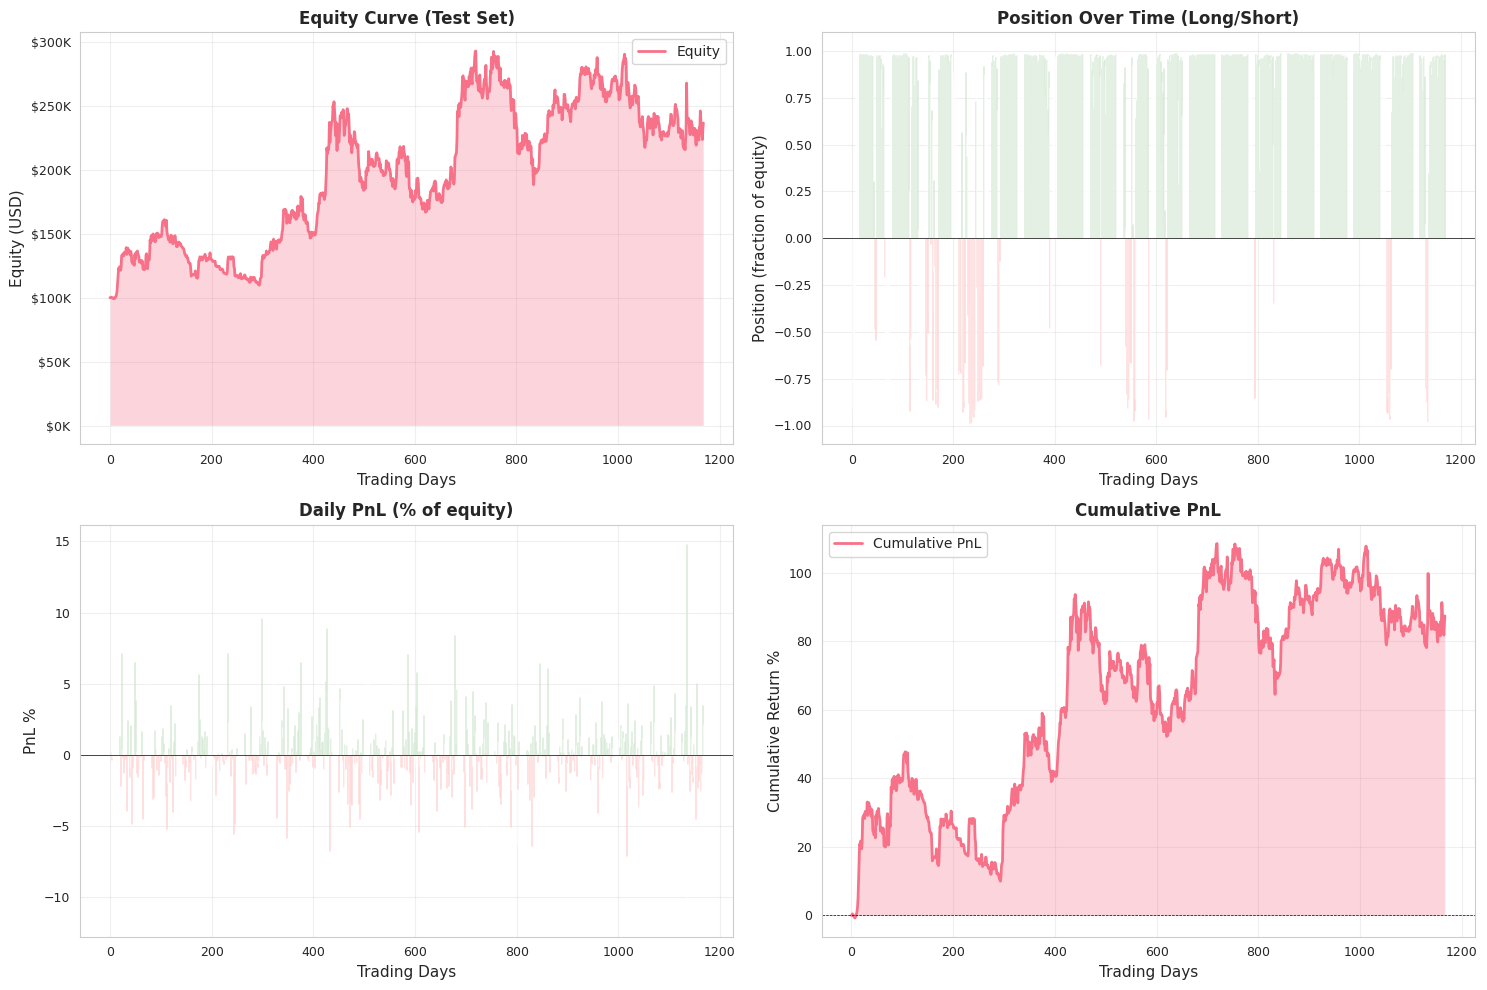


Visualization saved to 'enhanced_trading_analysis.png'


In [19]:
def run_equity_curve(model, df_eval):
    env_eval = TradingEnv_2(
        df_eval,
        fee=FEE,
        kappa=KAPPA,
        max_leverage=LEVERAGE_MAX,
    )
    obs, _ = env_eval.reset()
    done = False

    equity = [env_eval.equity]
    pos_hist = [env_eval.pos]
    pnl_hist = []
    cost_hist = []

    while not done:
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            dist, _ = model(obs_t)
            u = dist.mean
            a = squash(u)
            a_scaled = a * LEVERAGE_MAX

        obs, reward, terminated, truncated, info = env_eval.step(a_scaled.detach().cpu().numpy()[0])
        done = terminated or truncated
        equity.append(env_eval.equity)
        pos_hist.append(env_eval.pos)
        pnl_hist.append(info.get('pnl', 0.0))
        cost_hist.append(info.get('cost', 0.0))

    return np.array(equity), np.array(pos_hist), np.array(pnl_hist), np.array(cost_hist)
    obs, _ = env_eval.reset()
    done = False

    equity = [env_eval.equity]
    pos_hist = [env_eval.pos]
    pnl_hist = []
    cost_hist = []

    while not done:
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            dist, _ = model(obs_t)
            u = dist.mean
            a = squash(u)
            a_scaled = a * LEVERAGE_MAX

        obs, reward, terminated, truncated, info = env_eval.step(a_scaled.detach().cpu().numpy()[0])
        done = terminated or truncated
        equity.append(env_eval.equity)
        pos_hist.append(env_eval.pos)
        pnl_hist.append(info.get('pnl', 0.0))
        cost_hist.append(info.get('cost', 0.0))

    return np.array(equity), np.array(pos_hist), np.array(pnl_hist), np.array(cost_hist)

equity, pos_hist, pnl_hist, cost_hist = run_equity_curve(model, df_test)

# Print detailed statistics
print("\n" + "="*60)
print("EQUITY CURVE ANALYSIS WITH BUDGET TRACKING")
print("="*60)
print(f"\n--- INITIAL STATE ---")
print(f"Initial Budget: ${INITIAL_EQUITY:,.2f}")
print(f"Initial Equity: ${equity[0]:,.2f}")
print(f"Initial Cash: ${INITIAL_EQUITY:,.2f}")

print(f"\n--- FINAL STATE ---")
print(f"Final Equity: ${equity[-1]:,.2f}")
print(f"Total Return: {(equity[-1] / equity[0] - 1) * 100:.2f}%")
print(f"Absolute Gain/Loss: ${equity[-1] - equity[0]:,.2f}")
print(f"Peak Equity: ${np.max(equity):,.2f}")
print(f"Lowest Equity: ${np.min(equity):,.2f}")
print(f"Max Drawdown: {(1 - np.min(equity) / np.max(equity[:len(equity)//2])) * 100:.2f}%")

print(f"\n--- POSITION STATISTICS ---")
print(f"Mean position: {np.mean(pos_hist):.4f}")
print(f"Std position: {np.std(pos_hist):.4f}")
print(f"Min/Max position: {np.min(pos_hist):.4f} / {np.max(pos_hist):.4f}")
print(f"Number of position changes: {np.sum(np.abs(np.diff(pos_hist)) > 0.01)}")

print(f"\n--- TRADING STATISTICS ---")
print(f"Total days: {len(pos_hist)}")
print(f"Days with long position (>0): {np.sum(pos_hist > 0.01)}")
print(f"Days with short position (<0): {np.sum(pos_hist < -0.01)}")
print(f"Days with flat position (~0): {np.sum(np.abs(pos_hist) <= 0.01)}")
print(f"Total transaction costs: ${np.sum(cost_hist):,.2f}")
print(f"As % of initial equity: {np.sum(cost_hist) / INITIAL_EQUITY * 100:.4f}%")

print(f"\n--- PnL ANALYSIS ---")
print(f"Positive PnL days: {(pnl_hist > 0).sum()} / {len(pnl_hist)} ({(pnl_hist > 0).sum()/len(pnl_hist)*100:.1f}%)")
print(f"Negative PnL days: {(pnl_hist < 0).sum()} / {len(pnl_hist)} ({(pnl_hist < 0).sum()/len(pnl_hist)*100:.1f}%)")
print(f"Mean daily PnL: {np.mean(pnl_hist)*100:.4f}%")
print(f"Std daily PnL: {np.std(pnl_hist)*100:.4f}%")
print(f"Max daily gain: {np.max(pnl_hist)*100:.4f}%")
print(f"Max daily loss: {np.min(pnl_hist)*100:.4f}%")

print("="*60)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Equity Curve
ax = axes[0, 0]
ax.plot(equity, linewidth=2, label='Equity')
ax.fill_between(range(len(equity)), equity, alpha=0.3)
ax.set_title('Equity Curve (Test Set)', fontsize=12, fontweight='bold')
ax.set_xlabel('Trading Days')
ax.set_ylabel('Equity (USD)')
ax.grid(True, alpha=0.3)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e3:.0f}K'))

# 2. Position History
ax = axes[0, 1]
colors = ['green' if p > 0 else 'red' for p in pos_hist]
ax.bar(range(len(pos_hist)), pos_hist, color=colors, alpha=0.6)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Position Over Time (Long/Short)', fontsize=12, fontweight='bold')
ax.set_xlabel('Trading Days')
ax.set_ylabel('Position (fraction of equity)')
ax.set_ylim([-1.1, 1.1])
ax.grid(True, alpha=0.3)

# 3. Daily Returns Distribution
ax = axes[1, 0]
colors_pnl = ['green' if p > 0 else 'red' for p in pnl_hist]
ax.bar(range(len(pnl_hist)), pnl_hist * 100, color=colors_pnl, alpha=0.6)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('Daily PnL (% of equity)', fontsize=12, fontweight='bold')
ax.set_xlabel('Trading Days')
ax.set_ylabel('PnL %')
ax.grid(True, alpha=0.3)

# 4. Cumulative PnL
ax = axes[1, 1]
cumulative_pnl = np.cumsum(pnl_hist) * 100
ax.plot(cumulative_pnl, linewidth=2, label='Cumulative PnL')
ax.fill_between(range(len(cumulative_pnl)), cumulative_pnl, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Cumulative PnL', fontsize=12, fontweight='bold')
ax.set_xlabel('Trading Days')
ax.set_ylabel('Cumulative Return %')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('/home/isc-den/cas-artificial-intelligence/15_project_teil_b/Agent/enhanced_trading_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved to 'enhanced_trading_analysis.png'")
